In [1]:
import utils
from utils import DataGenerator, Reservoir
import pyro as py
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
Time_steps = 1500
tau = 17
n = 10
beta = 0.2
gamma = 0.1
delta_t = 0.1

X, Y = DataGenerator(Time_steps, tau, n, beta, gamma, delta_t).generate_data()
X.shape, Y.shape

((1500, 1), (1500, 1))

In [3]:
X_train = X[:1000,:]
X_test = X[1000:,:]
X_train.shape, X_test.shape

((1000, 1), (500, 1))

Input shape: (1000, 1)
Reservoir States shape: (1000, 500)


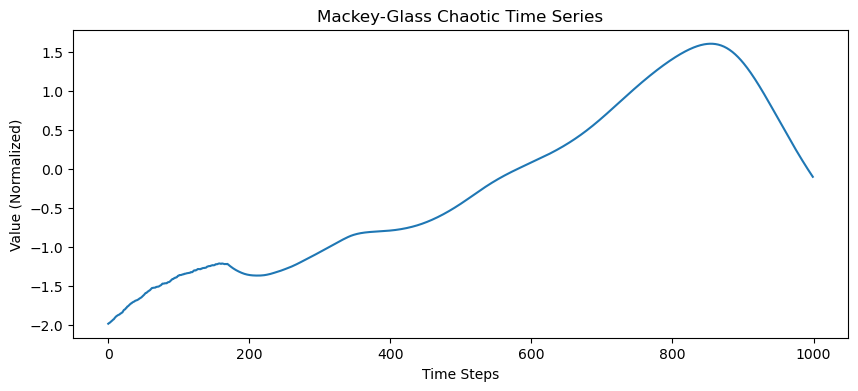

In [4]:
input_dim = X_train.shape[1]
reservoir_dim = 500
spectral_radius = 0.9
seed = 42

res = Reservoir(input_dim, reservoir_dim, spectral_radius, seed)

S_train = res.get_states(X_train)
S_test = res.get_states(X_test)

print(f"Input shape: {X_train.shape}")
print(f"Reservoir States shape: {S_train.shape}")

plt.figure(figsize=(10, 4))
plt.plot(X_train)
plt.title("Mackey-Glass Chaotic Time Series")
plt.xlabel("Time Steps")
plt.ylabel("Value (Normalized)")
plt.show()

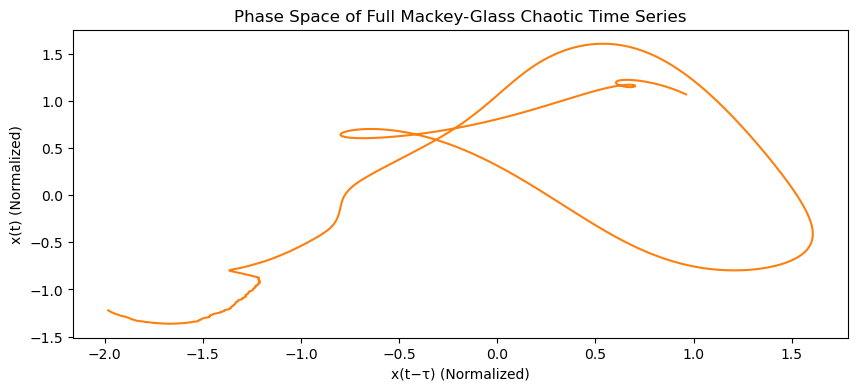

In [5]:
delay_steps = int(tau / delta_t)

plt.figure(figsize=(10, 4))
plt.plot(X[:-delay_steps], X[delay_steps:], color='C1')
plt.title("Phase Space of Full Mackey-Glass Chaotic Time Series")
plt.xlabel("x(t−τ) (Normalized)")
plt.ylabel("x(t) (Normalized)")
plt.show()

In [6]:
n_components = 16

S_train_PCA, S_test_PCA = utils.get_reduced_states(Reservoir(input_dim, reservoir_dim, spectral_radius, seed), X_train, X_test, n_components)

Original dim: (1000, 500)
Reduced dim:  (1000, 16)


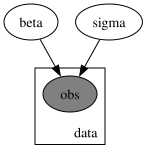

In [7]:
from methods import model
import pyro 
Y_train = Y[:1000]
pyro.render_model(model, model_args=(S_train_PCA, Y_train))

$
\text{TotalCost}_{\text{HMC}} \approx (\text{Num Samples})\times(\text{Leapfrog Steps per Sample})\times(\text{Gradient Cost}),
$
with:
+ $\text{Gradient Cost} \sim \texttt{TimeSteps}\times\texttt{input\_dim}$
+ $\text{Leapfrog Steps} \sim \operatorname{O}(\texttt{input\_dim})$

Thus run $\text{HMC}$ sampler to sample $Y$. Two parameters will be shown. The $\texttt{step size}\,\,\Delta t$ is the integration step by used by the Leapfrog integrator. Pyro automatically identifies the value that allow to safely explore the whole distribution. The $\texttt{acc. prob}$ which is the frequency with which the sampler accepts the new proposed state at the end of a trajectory.

In [8]:
num_samples = 500

nut_kernel = pyro.infer.NUTS(model)
mcmc = pyro.infer.MCMC(nut_kernel, num_samples=num_samples, warmup_steps=200)
mcmc.run(S_train_PCA, Y_train)

Sample: 100%|██████████| 700/700 [01:30,  7.70it/s, step size=6.75e-02, acc. prob=0.947]


In [9]:
param_samples = mcmc.get_samples()

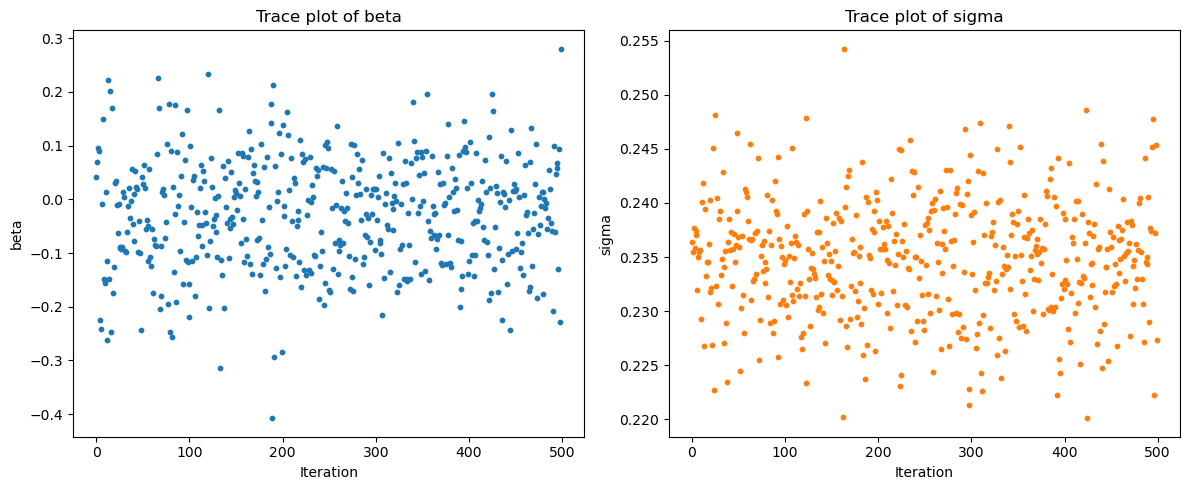

In [10]:
beta_samples = param_samples['beta'].squeeze().mean(1)
sigma_samples = param_samples['sigma'].squeeze()

iterations = np.arange(len(beta_samples))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(iterations, beta_samples, s=10, alpha=1)
plt.xlabel("Iteration")
plt.ylabel("beta")
plt.title("Trace plot of beta")

plt.subplot(1,2,2)
plt.scatter(iterations, sigma_samples, s=10, alpha=1, color="C1")
plt.xlabel("Iteration")
plt.ylabel("sigma")
plt.title("Trace plot of sigma")

plt.tight_layout()
plt.show()

In [11]:
# import arviz as az
# az.plot_trace(mcmc)

The trajectory outlines a Posterior Predictive Distribution that allows to estimate the uncertainty in the MAP estimates in $\beta$ and $\sigma$, which is the ultimate goal of our Bayesian Reservoir Computer.

In [12]:
Y_test = Y[1000:]
predictive = pyro.infer.Predictive(model, posterior_samples=param_samples, num_samples=None, parallel=True)
y_pred_samples = predictive(S_test_PCA, None)["obs"]

print("Shape of predictions:", y_pred_samples.shape)

Shape of predictions: torch.Size([500, 500])


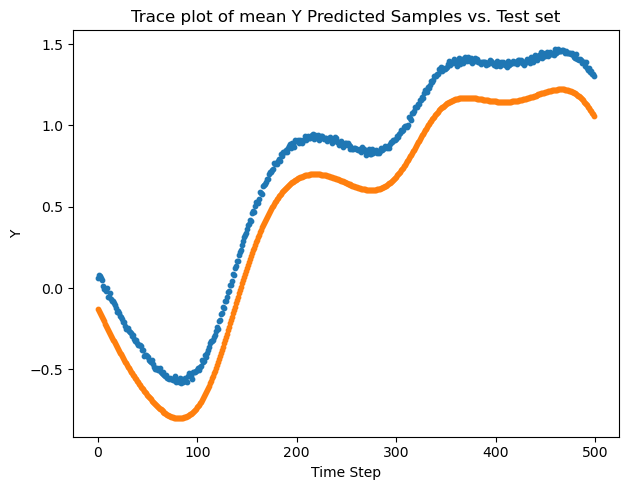

In [13]:
iterations = np.arange(len(y_pred_samples.mean(0)))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(iterations, y_pred_samples.mean(0), s=10, alpha=1)
plt.scatter(iterations, Y_test, s=10, alpha=1)
plt.xlabel("Time Step")
plt.ylabel("Y")
plt.title("Trace plot of mean Y Predicted Samples vs. Test set")
plt.tight_layout()
plt.show()